In [1]:


# Imports
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 200)


In [2]:
from google.colab import files
uploaded = files.upload()  # choose netflix_titles.csv from your machine
# after upload:
df = pd.read_csv(list(uploaded.keys())[0])


Saving netflix_titles.csv to netflix_titles.csv


In [4]:
from google.colab import drive
drive.mount('/content/drive')
# then load, e.g. if file is in MyDrive
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:

df.head()



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Ma...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [7]:
df.shape
df.isnull().sum().sort_values(ascending=False).head(10)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [10]:
# cleaning
# 1. Drop exact duplicate rows if any
df = df.drop_duplicates()


In [11]:

# 2. Create a 'title' column if necessary and strip whitespace
df['title'] = df['title'].astype(str).str.strip()

In [12]:
# 3. Fill missing descriptions or 'cast' columns with empty string
for col in ['description', 'cast', 'country', 'listed_in', 'director']:
    if col in df.columns:
        df[col] = df[col].fillna('')

In [13]:
# 4. Optional: convert release year to int (if present)
if 'release_year' in df.columns:
    df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')

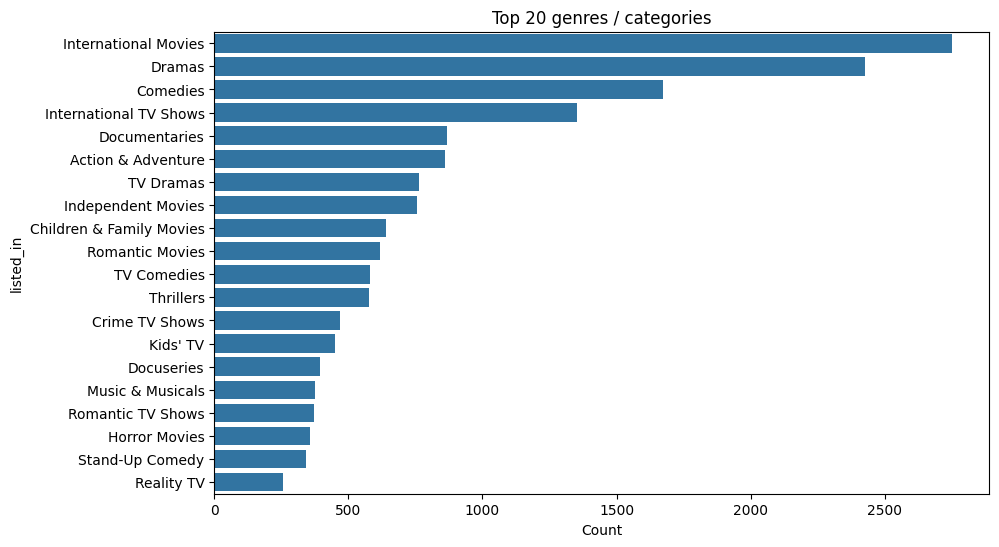

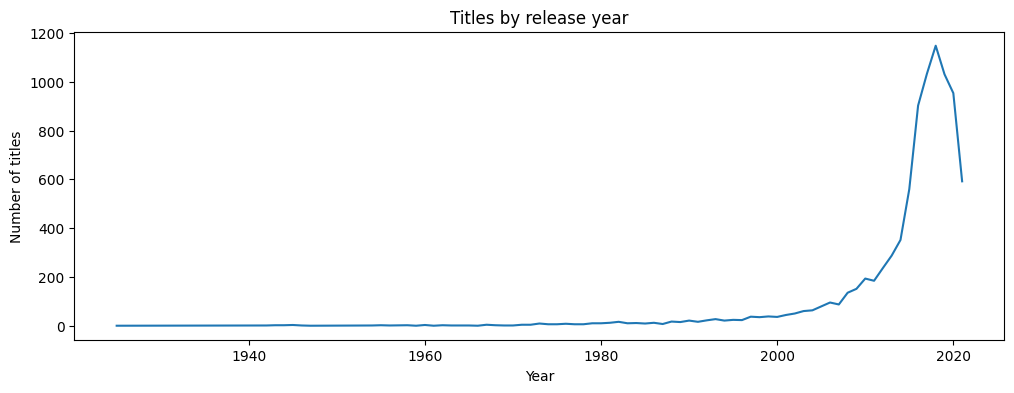

In [14]:
# genre distribution (listed_in often holds comma-separated genres)
if 'listed_in' in df.columns:
    # explode genres
    genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(20)
    plt.figure(figsize=(10,6))
    sns.barplot(x=genres.values, y=genres.index)
    plt.title('Top 20 genres / categories')
    plt.xlabel('Count')
    plt.show()

# Ratings over years (if available)
if 'release_year' in df.columns:
    year_counts = df['release_year'].dropna().astype(int).value_counts().sort_index()
    plt.figure(figsize=(12,4))
    plt.plot(year_counts.index, year_counts.values)
    plt.title('Titles by release year')
    plt.xlabel('Year')
    plt.ylabel('Number of titles')
    plt.show()


In [19]:
#  create a content column
text_features = []
for f in ['title','description','listed_in','cast','director','country']:
    if f in df.columns:
        text_features.append(f)

def combine_text(row):
    return ' '.join([str(row[c]) for c in text_features if c in row.index and pd.notna(row[c])])

df['content'] = df.apply(combine_text, axis=1)

# quick sample
df[['title','content']].head()


,title,content
0,Dick Johnson Is Dead,"Dick Johnson Is Dead As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable. Documentaries Kirsten..."
1,Blood & Water,"Blood & Water After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth. International TV Shows, TV Dramas,..."
2,Ganglands,"Ganglands To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war. Crime TV Shows, International TV Shows,..."
3,Jailbirds New Orleans,"Jailbirds New Orleans Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series. Docuseries, Reality TV"
4,Kota Factory,"Kota Factory In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life. International TV Shows, Romant..."


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(stop_words='english', max_features=50000)
tfidf_matrix = tfidf.fit_transform(df['content'])

# compute cosine similarity — note: full matrix can be large (n x n)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)  # dense numpy array
# If memory is an issue, compute similarity on the fly for a single query using vector dot.

In [22]:
#  helper to map title -> index
indices = pd.Series(df.index, index=df['title'].str.lower()).drop_duplicates()

def get_recommendations(title, top_n=10):
    # handle case-insensitive match
    key = title.strip().lower()
    if key not in indices:
        return f"Title '{title}' not found. Try exact title or check case/punctuation."
    idx = indices[key]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1: top_n+1]  # skip self
    movie_indices = [i for i, score in sim_scores]
    return df.iloc[movie_indices][['title','release_year','listed_in']].reset_index(drop=True)

# Example usage:
get_recommendations('The Irishman', top_n=5)  # replace with a title present in your DF


,title,release_year,listed_in
0,The Irishman: In Conversation,2019,Documentaries
1,GoodFellas,1990,"Classic Movies, Dramas"
2,Raging Bull,1980,"Classic Movies, Dramas, Sports Movies"
3,Sebastian Maniscalco: Why Would You Do That,2016,Stand-Up Comedy
4,Who's That Knocking at My Door?,1967,"Classic Movies, Dramas, Independent Movies"


In [25]:
#  recommend based on user's watched list
def recommend_from_user_history(watched_titles, top_n=10):
    valid_idxs = []
    for t in watched_titles:
        tkey = t.strip().lower()
        if tkey in indices:
            valid_idxs.append(indices[tkey])
    if not valid_idxs:
        return "No valid titles found in the watched list."

    # average TF-IDF vector of watched items
    user_vec = np.asarray(tfidf_matrix[valid_idxs].mean(axis=0)) # Convert to ndarray
    distances = cosine_similarity(user_vec, tfidf_matrix).flatten()
    top_idx = distances.argsort()[::-1]
    # remove items already watched
    top_idx = [i for i in top_idx if i not in valid_idxs]
    top_idx = top_idx[:top_n]
    return df.iloc[top_idx][['title','release_year','listed_in']].reset_index(drop=True)

# Example:
recommend_from_user_history(['Stranger Things', 'The Witcher'], top_n=10)

,title,release_year,listed_in
0,Beyond Stranger Things,2017,"Stand-Up Comedy & Talk Shows, TV Mysteries, TV Sci-Fi & Fantasy"
1,The Witcher: A Look Inside the Episodes,2020,"Docuseries, TV Sci-Fi & Fantasy"
2,Making The Witcher,2020,Documentaries
3,Prank Encounters,2021,"Reality TV, TV Comedies, TV Horror"
4,The Irregulars,2021,"British TV Shows, Crime TV Shows, International TV Shows"
5,Kiss Me First,2018,"British TV Shows, Crime TV Shows, International TV Shows"
6,Ripper Street,2017,"British TV Shows, Crime TV Shows, TV Dramas"
7,Q-Force,2021,"Crime TV Shows, TV Action & Adventure, TV Comedies"
8,The Umbrella Academy,2020,"TV Action & Adventure, TV Mysteries, TV Sci-Fi & Fantasy"
9,Haunted,2021,"Reality TV, TV Horror, TV Thrillers"


In [27]:
#save TF-IDF
import joblib
joblib.dump(tfidf, '/content/drive/MyDrive/netflix_tfidf.pkl')  # change path as needed

# If you want to save a precomputed small similarity subset:
# joblib.dump(cosine_sim, '/content/drive/MyDrive/netflix_cosine.npy')


['/content/drive/MyDrive/netflix_tfidf.pkl']